In [1]:
#Inicio importando las librerias que necesito
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt 

In [2]:
#Carga del dataset de Sabadell en Python
df_datasabadell = pd.read_csv(r'C:\Users\jmendozarojas\OneDrive - Getronics\Escritorio\INESDI\TFM\MUESTRA_UB.csv', sep=';', header='infer', encoding='latin-1', engine='python')


In [3]:
#Realizamos la confirmación de la carga
df_datasabadell.head()

,id_cliente,antig,edad,totalpasta,impoped,impopeh,ind_cuentaexpansion,ind_cuentaexpansionnegocios,ind_cuentaexpansionpremium,ind_cuentaexperiencia,...,prov,credit,revolving,tothipo,nominaimp,rdom,tpv,margecomercialut,total_proteccio,fase
0,1,194,84,52043.01,5516.79,23100.89,1,0,0,0,...,28,0.0,0.0,0.0,0.00,38,0,105.19,0,29.0
1,2,244,75,4219.46,744.74,0.00,0,0,0,0,...,8,0.0,0.0,0.0,0.00,4,0,32.42,0,30.0
2,3,336,84,55585.45,1152.96,400.20,0,0,0,0,...,8,0.0,0.0,0.0,0.00,4,0,123.41,0,30.0
3,4,278,55,5813.22,11449.97,15317.10,0,0,0,0,...,28,0.0,0.0,0.0,12645.48,41,0,22.51,0,16.0
4,5,36,55,19000.00,0.00,0.00,0,0,0,0,...,28,0.0,0.0,0.0,0.00,0,0,28.26,0,27.0


In [4]:
#funcion para identificar los campos nulos de la tabla
print("Nulos por columna:")
print(df_datasabadell.isnull().sum())

Nulos por columna:
id_cliente            0
antig                 0
edad                  0
totalpasta            0
impoped               0
                   ... 
rdom                  0
tpv                   0
margecomercialut      0
total_proteccio       0
fase                114
Length: 84, dtype: int64


In [5]:
#Consultamos la tabla
df_datasabadell.head()

,id_cliente,antig,edad,totalpasta,impoped,impopeh,ind_cuentaexpansion,ind_cuentaexpansionnegocios,ind_cuentaexpansionpremium,ind_cuentaexperiencia,...,prov,credit,revolving,tothipo,nominaimp,rdom,tpv,margecomercialut,total_proteccio,fase
0,1,194,84,52043.01,5516.79,23100.89,1,0,0,0,...,28,0.0,0.0,0.0,0.00,38,0,105.19,0,29.0
1,2,244,75,4219.46,744.74,0.00,0,0,0,0,...,8,0.0,0.0,0.0,0.00,4,0,32.42,0,30.0
2,3,336,84,55585.45,1152.96,400.20,0,0,0,0,...,8,0.0,0.0,0.0,0.00,4,0,123.41,0,30.0
3,4,278,55,5813.22,11449.97,15317.10,0,0,0,0,...,28,0.0,0.0,0.0,12645.48,41,0,22.51,0,16.0
4,5,36,55,19000.00,0.00,0.00,0,0,0,0,...,28,0.0,0.0,0.0,0.00,0,0,28.26,0,27.0


In [6]:
#Función para contar la cantidad total de clientes en la BD
total_clientes=df_datasabadell.id_cliente.count()
print(f"El total de clientes registrados en la BD es : {total_clientes}")


El total de clientes registrados en la BD es : 10000


In [7]:
#Analisis de los datos atipicos, conteo e identificación 
cantidad_9999 = (df_datasabadell['antig'] == 9999).sum()
print(f"Cantidad de registros con antig == '9999, posibles datos atipicos': {cantidad_9999}")



Cantidad de registros con antig == '9999, posibles datos atipicos': 64


In [14]:
#Opción #1: Transformación de los valores Anómalos, realizar la transformación a un valor consistente seleccionamos 600 meses que equivale a 50 años de antiguedad  
df_datasabadell['antig'] = df_datasabadell['antig'].replace(9999, 600)

In [8]:
#Opción 2: Eliminar los 64 registros con esos valores antig=9999
df_delete = df_datasabadell[df_datasabadell['antig'] == 9999].copy()
print(f"CORRECCIÓN: Registros con antig == 9999 (para eliminar): {len(df_delete)}")


CORRECCIÓN: Registros con antig == 9999 (para eliminar): 64


In [9]:
df_delete.head()

,id_cliente,antig,edad,totalpasta,impoped,impopeh,ind_cuentaexpansion,ind_cuentaexpansionnegocios,ind_cuentaexpansionpremium,ind_cuentaexperiencia,...,prov,credit,revolving,tothipo,nominaimp,rdom,tpv,margecomercialut,total_proteccio,fase
1474,1475,9999,60,0.00,205.49,0.0,0,0,0,0,...,24,0.0,0.0,0.0,0.0,0,0,-0.09,0,27.0
1600,1601,9999,37,0.00,495.02,0.0,0,0,0,0,...,8,0.0,0.0,0.0,0.0,0,0,0.61,0,9.0
2304,2305,9999,40,6428.52,0.00,0.0,0,0,0,0,...,3,0.0,0.0,0.0,0.0,0,0,46.27,0,9.0
2711,2712,9999,57,0.00,0.00,0.0,0,0,0,0,...,7,0.0,0.0,0.0,0.0,0,0,144.15,1,27.0
2737,2738,9999,45,0.00,427.58,0.0,0,0,0,0,...,28,0.0,0.0,0.0,0.0,0,0,0.50,0,18.0


In [10]:
# Para eliminar realmente del DataFrame principal
df_datasabadell = df_datasabadell[df_datasabadell['antig'] != 9999]

print("\nEliminados los registros con valores 9999")


Eliminados los registros con valores 9999


In [11]:

#Segementacion de clientes por tipo de cuenta 
# Lista de columnas a seleccionar
columnas_seleccion = [
    'id_cliente',
    'ind_cuentaexpansion',
    'ind_cuentaexpansionnegocios',
    'ind_cuentaexpansionpremium',
    'ind_cuentaexperiencia',
    'ind_cuentaprimera',
    'ind_cuentaproyeccion',
    'ind_cvautonomos',
    'ind_cvdirect',
    'ind_cvhabit',
    'ind_cvjove',
    'ind_cvjunior',
    'ind_cvmas',
    'ind_cvprestige',
    'ind_cvsenior',
    'ind_estalinv',
    'ind_estalvi',
    'ind_estrangers'
]

# Seleccionar las columnas (syntax correcta)
df_tipocuenta = df_datasabadell[columnas_seleccion].copy()



In [12]:
df_tipocuenta.head()

,id_cliente,ind_cuentaexpansion,ind_cuentaexpansionnegocios,ind_cuentaexpansionpremium,ind_cuentaexperiencia,ind_cuentaprimera,ind_cuentaproyeccion,ind_cvautonomos,ind_cvdirect,ind_cvhabit,ind_cvjove,ind_cvjunior,ind_cvmas,ind_cvprestige,ind_cvsenior,ind_estalinv,ind_estalvi,ind_estrangers
0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
3,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0


In [27]:
# Función para realizar group by por tipo de cuenta y contar cuántas personas tienen ese tipo de cuenta (sumar cuando el tipo de cuenta sea igual a 1)
def group_by_tipo_cuenta(df, account_columns):
       
    # Verificar que las columnas existan en el DataFrame
    missing_columns = [col for col in account_columns if col not in df.columns]
    if missing_columns:
        print(f"Advertencia: Las siguientes columnas no existen en el DataFrame: {missing_columns}")
        # Remover columnas faltantes de la lista
        account_columns = [col for col in account_columns if col not in missing_columns]
    
    # Crear un DataFrame para almacenar los resultados
    results = []
    
    for account_type in account_columns:
        # Contar cuántas personas tienen esta cuenta (valor = 1)
        count = df[df[account_type] == 1][account_type].count()
        
        # Calcular porcentaje del total
        total_clients = df['id_cliente'].nunique()  # Usar nunique para contar clientes únicos
        percentage = (count / total_clients) * 100 if total_clients > 0 else 0
        
        results.append({
            'Tipo de Cuenta': account_type,
            'Cantidad': count,
            'Porcentaje': f"{percentage:.2f}%"
        })
    
    # Crear DataFrame de resultados
    results_df = pd.DataFrame(results)
    
    # Ordenar por cantidad de personas de mayor a menor
    results_df = results_df.sort_values(by='Cantidad', ascending=False)
    
    return results_df

# También necesitas definir columnas_cuenta (sin 'id_cliente')
columnas_cuenta = [
    'ind_cuentaexpansion',
    'ind_cuentaexpansionnegocios',
    'ind_cuentaexpansionpremium',
    'ind_cuentaexperiencia',
    'ind_cuentaprimera',
    'ind_cuentaproyeccion',
    'ind_cvautonomos',
    'ind_cvdirect',
    'ind_cvhabit',
    'ind_cvjove',
    'ind_cvjunior',
    'ind_cvmas',
    'ind_cvprestige',
    'ind_cvsenior',
    'ind_estalinv',
    'ind_estalvi',
    'ind_estrangers'
]


In [28]:

# Usar la función con df_datasabadell en lugar de df_tipocuenta
# IMPORTANTE: Primero el DataFrame, luego las columnas
resultados = group_by_tipo_cuenta(df_datasabadell, columnas_cuenta)
print(resultados)


                 Tipo de Cuenta  Cantidad Porcentaje
0           ind_cuentaexpansion      3472     34.94%
14                 ind_estalinv      3337     33.58%
15                  ind_estalvi      3061     30.81%
16               ind_estrangers       984      9.90%
3         ind_cuentaexperiencia       804      8.09%
9                    ind_cvjove       660      6.64%
5          ind_cuentaproyeccion       660      6.64%
4             ind_cuentaprimera       541      5.44%
10                 ind_cvjunior       541      5.44%
12               ind_cvprestige       355      3.57%
2    ind_cuentaexpansionpremium       228      2.29%
7                  ind_cvdirect       138      1.39%
13                 ind_cvsenior        80      0.81%
1   ind_cuentaexpansionnegocios        70      0.70%
11                    ind_cvmas        35      0.35%
6               ind_cvautonomos        11      0.11%
8                   ind_cvhabit         2      0.02%


In [33]:
# Contar cuántos clientes tienen cada indicador activo
conteo_indicadores = {}  # <- DEFINIR EL DICCIONARIO PRIMERO

for col in columnas_seleccion:
    if col != 'id_cliente' and col in df_tipocuenta.columns:
        # Asumiendo que los indicadores son binarios (0/1 o True/False)
        conteo = df_tipocuenta[col].sum() if df_tipocuenta[col].dtype in [int, float, bool] else len(df_tipocuenta[df_tipocuenta[col] == True])
        conteo_indicadores[col] = conteo  # <- Ahora sí está definido
print(conteo_indicadores)  # Mostrar todos los conteos, no solo el último


{'ind_cuentaexpansion': np.int64(3472), 'ind_cuentaexpansionnegocios': np.int64(70), 'ind_cuentaexpansionpremium': np.int64(228), 'ind_cuentaexperiencia': np.int64(804), 'ind_cuentaprimera': np.int64(541), 'ind_cuentaproyeccion': np.int64(660), 'ind_cvautonomos': np.int64(11), 'ind_cvdirect': np.int64(138), 'ind_cvhabit': np.int64(2), 'ind_cvjove': np.int64(660), 'ind_cvjunior': np.int64(541), 'ind_cvmas': np.int64(35), 'ind_cvprestige': np.int64(355), 'ind_cvsenior': np.int64(80), 'ind_estalinv': np.int64(3337), 'ind_estalvi': np.int64(3061), 'ind_estrangers': np.int64(984)}


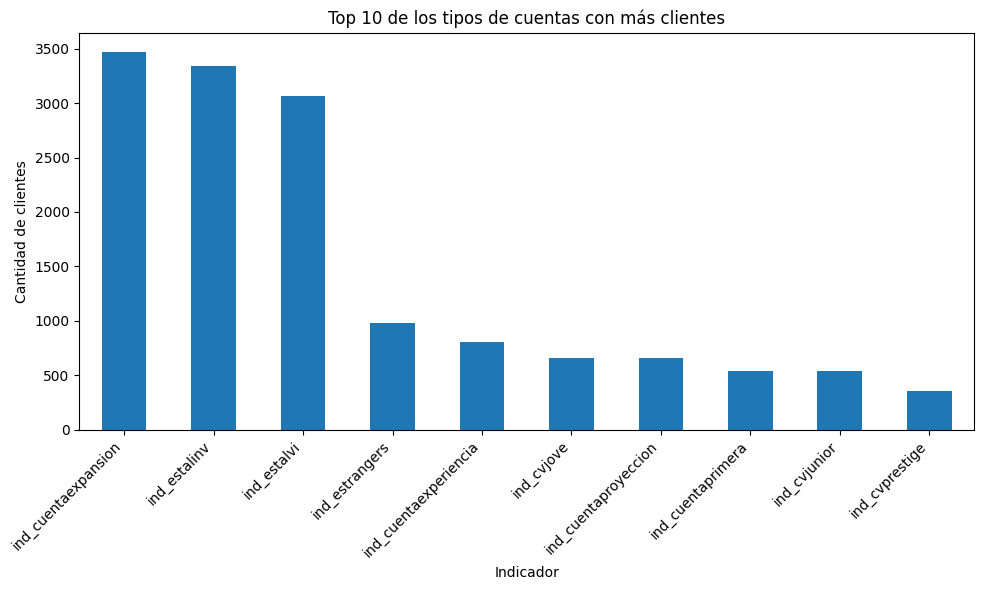

In [34]:
# Crear gráfico (funcionará ahora que conteo_indicadores está definido)
pd.Series(conteo_indicadores).sort_values(ascending=False).head(10).plot(
    kind='bar',
    title='Top 10 de los tipos de cuentas con más clientes',
    figsize=(10, 6)
)
plt.xlabel('Indicador')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [36]:
df_datasabadell.to_excel(r'C:\Users\jmendozarojas\OneDrive - Getronics\Escritorio\INESDI\TFM\actualizado_tfm.xlsx')
